# Użycie "twarzy własnych" (eigenfaces)

Rozmiar macierzy faces: (32256, 2410)
Rozmiar U_style: (32256, 2410)
Dla k=45% wyznaczona liczba składowych wynosi r = 86


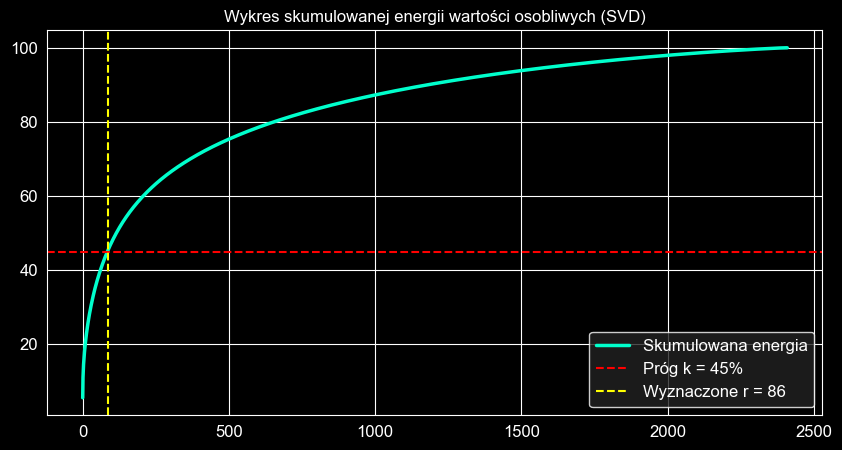

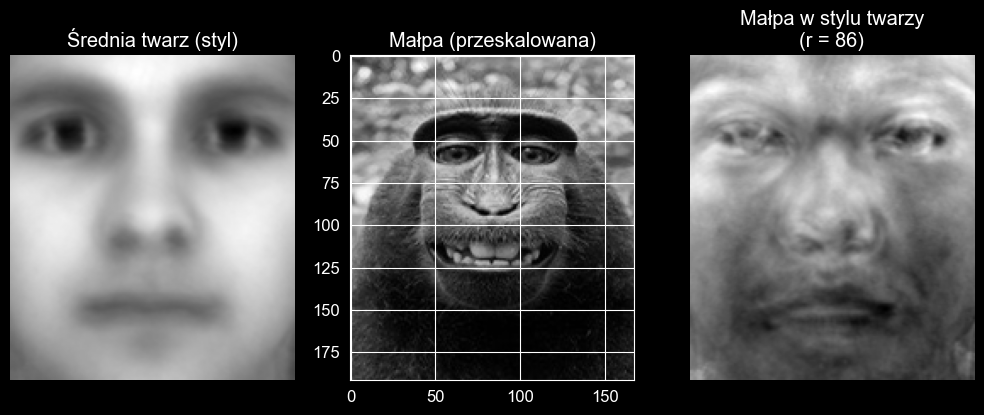

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os
import requests
from io import BytesIO
from PIL import Image

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams.update({'font.size': 12})

# -------------------------------------------------------------
# 1. Wczytanie bazy twarzy i obliczenie stylu (średnia + U)
# -------------------------------------------------------------
mat_path = os.path.join('allFaces.mat')
mat = scipy.io.loadmat(mat_path)

faces = mat['faces']      # każda kolumna = jedna twarz (spłaszczona)
m = int(mat['m'][0][0])         # liczba wierszy obrazka
n = int(mat['n'][0][0])         # liczba kolumn obrazka

print("Rozmiar macierzy faces:", faces.shape)  # (m*n, liczba_twarzy)

# Możemy użyć całej bazy jako "biblioteki stylu"
faces_style = faces

# Średnia twarz stylu
avgFace_style = np.mean(faces_style, axis=1, keepdims=True)

# Mean-subtraction
X_style = faces_style - avgFace_style

# SVD: X = U S V^T
U_style, S_style, VT_style = np.linalg.svd(X_style, full_matrices=False)
print("Rozmiar U_style:", U_style.shape)

# -------------------------------------------------------------
# 2. Funkcja: wczytaj obraz i zamień na wektor
# -------------------------------------------------------------
def load_image_as_vector_from_url(url, m, n):
    """
    Pobiera obraz z danego URL, konwertuje do skali szarości,
    zmienia rozmiar na (m, n), a następnie spłaszcza do wektora (m*n,).
    """
    response = requests.get(url)
    response.raise_for_status()  # zgłosi błąd, jeśli URL jest zły

    img = Image.open(BytesIO(response.content))

    # Skala szarości
    img = img.convert('L')

    # Zmiana rozmiaru na (n szerokość, m wysokość)
    img = img.resize((n, m))

    # Konwersja do tablicy numpy (m, n)
    img_arr = np.array(img, dtype=np.float64)

    # UWAGA: w oryginalnych twarzach jest reshape(...).T,
    # więc robimy transpozycję, żeby zachować ten sam układ.
    img_arr = img_arr.T  # teraz (n, m) -> (m, n) po .T przy wyświetlaniu

    # Spłaszczamy do wektora
    vec = img_arr.reshape(m * n)

    # (opcjonalnie) skalowanie do zakresu jak w faces
    # Sprawdź w swoim środowisku:
    # print(faces.min(), faces.max())
    # Jeśli faces są np. w [0, 1], warto podzielić przez 255:
    # vec = vec / 255.0

    return vec

# -------------------------------------------------------------
# 3. Funkcja: narzuć styl eigenfaces na nowy obraz
# -------------------------------------------------------------
def stylize_face(newFace_vec, avgFace_style, U_style, r):
    """
    newFace_vec: wektor (m*n,)
    avgFace_style: średnia twarz (m*n, 1)
    U_style: macierz eigenfaces (m*n, k)
    r: liczba pierwszych eigenfaces do użycia
    """
    newFace_vec = newFace_vec.reshape(-1)          # na wszelki wypadek
    faceMS = newFace_vec - avgFace_style[:, 0]     # odejmujemy średnią stylu

    Ur = U_style[:, :r]                            # pierwsze r eigenfaces
    coeffs = Ur.T @ faceMS                         # współczynniki projekcji
    recon = avgFace_style[:, 0] + Ur @ coeffs      # rekonstrukcja w stylu

    return recon

# -------------------------------------------------------------
# 4. Przykład użycia: obraz "małpy" z internetu
# -------------------------------------------------------------


# Wczytanie obrazu małpy jako wektora


from PIL import Image
import numpy as np

def load_image_as_vector_from_file(path, m, n):
    img = Image.open(path).convert('L')
    img = img.resize((n, m))
    #img_arr = np.array(img, dtype=np.float64).T
    img_arr = np.array(img, dtype=np.float64)
    return img_arr.reshape(m * n)

monkey_vec = load_image_as_vector_from_file("malpa1.jpg", m, n)


# Stylizacja: projekcja na podprzestrzeń eigenfaces

# liczba eigenfaces - wyznaczenie r dla progu 45%
k=45
energia_calkowita = np.sum(S_style)
energia_kumulatywna = np.cumsum(S_style) / energia_calkowita * 100
r = np.argmax(energia_kumulatywna >= k) + 1

print(f"Dla k=45% wyznaczona liczba składowych wynosi r = {r}")
plt.figure(figsize=(10, 5))
plt.plot(energia_kumulatywna, color='#00ffcc', linewidth=2.5, label='Skumulowana energia')
plt.axhline(y=k, color='red', linestyle='--', linewidth=1.5, label=f'Próg k = {k}%')
plt.axvline(x=r, color='yellow', linestyle='--', linewidth=1.5, label=f'Wyznaczone r = {r}')
plt.title('Wykres skumulowanej energii wartości osobliwych (SVD)', color='white', fontsize=12)
plt.legend(facecolor='#222222', edgecolor='white', labelcolor='white')
plt.show()
#r = 50
monkey_styled = stylize_face(monkey_vec, avgFace_style, U_style, r)

# -------------------------------------------------------------
# 5. Wizualizacja: oryginał vs wersja w stylu twarzy
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3)

# 1. Średnia twarz stylu (dla porównania)
axes[0].imshow(avgFace_style.reshape(m, n).T, cmap='gray')
axes[0].set_title("Średnia twarz (styl)")
axes[0].axis('off')

# 2. Oryginalny obraz małpy po przeskalowaniu
axes[1].imshow(monkey_vec.reshape(m, n).T, cmap='gray')
axes[1].set_title("Małpa (przeskalowana)")
axes[1].axis('on')

# 3. Małpa w stylu biblioteki twarzy
axes[2].imshow(monkey_styled.reshape(m, n).T, cmap='gray')
axes[2].set_title(f"Małpa w stylu twarzy\n(r = {r})")
axes[2].axis('off')

plt.tight_layout()
plt.show()
